# Финальная модель с расширенными признаками

## Идея

В этом ноутбуке строится улучшенная версия модели прогноза GMV на 30 дней.

Сначала для каждой anchor-даты формируются snapshot-ы пользователей:
агрегаты за несколько временных окон, lifetime-показатели и признаки давности активности.
Затем добавляются производные признаки тренда, recency и доли недавней активности.

После этого модель CatBoost проверяется на нескольких временных фолдах,
обучается на всех доступных anchor-датаx и используется для создания submission.

Дополнительно сравниваются несколько наборов признаков и возможные blend-прогнозы.

## Ожидаемый результат

В результате должны быть:

- кэшированные snapshot-ы для временной валидации и финального прогноза;
- оценка RMSLE на временных фолдах;
- выбранное количество итераций CatBoost;
- финальная модель и её важность признаков;
- submission для всех 250 000 пользователей;
- при необходимости — blended submission из нескольких моделей.

In [ ]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.6 MB/s eta 0:00:00


In [ ]:
import gc
from pathlib import Path
from datetime import date, timedelta

import numpy as np
import polars as pl
from catboost import CatBoostRegressor

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## Настройки запуска

Задаём пути к данным, кэшу и результатам.
Горизонт прогноза равен 30 дням, как в условиях соревнования.

Предусмотрены два режима:

- `quick` — меньше anchor-дата для быстрой проверки кода;
- `full` — полный набор anchor-дата для итоговой валидации.

Для запуска финальной модели используется режим `full`.

In [ ]:
BASE_DIR = Path("/content/drive/MyDrive/Colab Notebooks/e-cup")
DATA_PATH = BASE_DIR / "data/train.parquet"

CACHE_DIR = BASE_DIR / "data" / "enhanced_final_cache"
SUBMISSIONS_DIR = BASE_DIR / "submissions"

CACHE_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)

HORIZON = 30

# Полная историческая схема: 9 anchors -> 8 validation folds.
ALL_ANCHORS = [
    date(2025, 10, 1),
    date(2025, 10, 15),
    date(2025, 10, 29),
    date(2025, 11, 12),
    date(2025, 11, 26),
    date(2025, 12, 10),
    date(2025, 12, 24),
    date(2026, 1, 7),
    date(2026, 1, 14),
]

# Финальный anchor = первый день будущего периода.
# Данные заканчиваются 2026-02-13, поэтому прогноз начинается 2026-02-14.
FINAL_ANCHOR = date(2026, 2, 14)

# QUICK = последние 4 anchors -> 3 validation folds.
# FULL = все 9 anchors -> 8 validation folds.
MODE = "full"

# После успешного FULL CV изменить на True.
RUN_FINAL = True

print("MODE:", MODE)
print("Data:", DATA_PATH)
print("Cache:", CACHE_DIR)

MODE: full
Data: /content/drive/MyDrive/Colab Notebooks/e-cup/data/train.parquet
Cache: /content/drive/MyDrive/Colab Notebooks/e-cup/data/enhanced_final_cache


### Как запускать

Сначала оставить:

```python
MODE = "quick"
RUN_FINAL = False
```

Quick использует последние 4 anchors, поэтому получается 3 validation folds.

Если quick показывает хороший результат, поставить:

```python
MODE = "full"
```

и перезапустить ноутбук с этого места/после очистки RAM.

После успешного full CV поставить:

```python
RUN_FINAL = True
```

и запустить финальный блок.

## Проверка файла и RMSLE

Проверяем наличие исходного Parquet-файла и выводим его схему.

RMSLE рассчитывается в логарифмической шкале. Перед расчётом
предсказания ограничиваются снизу нулём, так как отрицательный GMV невозможен.

In [ ]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Файл не найден: {DATA_PATH}")

schema = pl.scan_parquet(DATA_PATH).collect_schema()
print(schema)

def rmsle(y_true, y_pred):
    y_true = np.clip(np.asarray(y_true, dtype=np.float64), 0, None)
    y_pred = np.clip(np.asarray(y_pred, dtype=np.float64), 0, None)
    return float(
        np.sqrt(
            np.mean(
                (np.log1p(y_true) - np.log1p(y_pred)) ** 2
            )
        )
    )

Schema({'event_date': Date, 'user_id': Int64, 'search': Int64, 'cat': Int64, 'has_search_to_cart': Int64, 'has_search_to_ord': Int64, 'has_cat_to_cart': Int64, 'has_cat_to_ord': Int64, 'search_to_cart': Int64, 'search_to_ord': Int64, 'cat_to_cart': Int64, 'cat_to_ord': Int64, 'gmv_search': Float64, 'gmv_cat': Float64, 'to_cart': Int64, 'to_ord': Int64, 'gmv': Float64, 'searches': Int64})


Финальная anchor-дата должна быть на один день позже последней даты истории.
Так признаки строятся по данным до 13 февраля 2026 года,
а прогноз относится к периоду после этой даты.

In [ ]:
# Проверка, что FINAL_ANCHOR не выходит за пределы данных
max_date = pl.scan_parquet(DATA_PATH).select(pl.col("event_date").max()).collect()["event_date"][0]
print(f"Max date in data: {max_date}")
print(f"FINAL_ANCHOR: {FINAL_ANCHOR}")

if FINAL_ANCHOR > max_date + timedelta(days=1):
    raise ValueError(
        f"FINAL_ANCHOR ({FINAL_ANCHOR}) выходит за пределы данных. "
        f"Max дата в данных: {max_date}. "
        f"Прогноз должен начинаться не позже {max_date + timedelta(days=1)}."
    )

print("FINAL_ANCHOR в пределах данных ✓")

Max date in data: 2026-02-13
FINAL_ANCHOR: 2026-02-14
FINAL_ANCHOR в пределах данных ✓


## Колонки для snapshot

Определяем столбцы для трёх частей расчёта:

- оконных агрегатов;
- lifetime-признаков;
- целевой переменной.

Используем окна 7, 30, 90, 180 и 365 дней:
короткие окна отражают текущую активность, длинные - устойчивое поведение пользователя.

In [ ]:
WINDOW_COLUMNS = [
    "user_id",
    "event_date",
    "gmv",
    "to_ord",
    "to_cart",
    "searches",
    "search",
    "cat",
    "has_search_to_ord",
    "has_cat_to_ord",
    "has_search_to_cart",
    "has_cat_to_cart",
    "gmv_search",
    "gmv_cat",
]

LIFETIME_COLUMNS = [
    "user_id",
    "event_date",
    "gmv",
    "to_ord",
    "to_cart",
    "searches",
]

TARGET_COLUMNS = [
    "user_id",
    "event_date",
    "gmv",
]

WINDOWS = [7, 30, 90, 180, 365]

## Формирование базового snapshot-а
Для каждой cutoff-даты создаём одну строку на пользователя.
В неё входят агрегаты активности за выбранные периоды,
статистика за всю историю и признаки давности последней активности.

Расчёт ограничен cutoff-датаx, поэтому признаки не используют будущие данные.

In [ ]:
def build_snapshot_exact(data_path, cutoff, windows):
    max_window = max(windows)

    window_exprs = []

    for w in windows:
        in_window = (
            (pl.col("event_date") >= cutoff - timedelta(days=w))
            & (pl.col("event_date") < cutoff)
        )

        def ws(column, name):
            return (
                pl.when(in_window)
                .then(pl.col(column))
                .otherwise(0)
                .sum()
                .cast(pl.Float32)
                .alias(f"{name}_{w}")
            )

        window_exprs.extend([
            ws("gmv", "gmv"),
            ws("to_ord", "orders"),
            ws("to_cart", "cart"),
            ws("searches", "searches"),
            ws("search", "search_days"),
            ws("cat", "cat_days"),
            ws("has_search_to_ord", "search_order_days"),
            ws("has_cat_to_ord", "cat_order_days"),
            ws("has_search_to_cart", "search_cart_days"),
            ws("has_cat_to_cart", "cat_cart_days"),
            ws("gmv_search", "gmv_search"),
            ws("gmv_cat", "gmv_cat"),
            (
                pl.when(in_window)
                .then(pl.col("event_date"))
                .otherwise(None)
                .n_unique()
                .cast(pl.Float32)
                .alias(f"active_days_{w}")
            ),
        ])

    windows_df = (
        pl.scan_parquet(data_path)
        .select(WINDOW_COLUMNS)
        .with_columns(pl.col("event_date").cast(pl.Date))
        .filter(
            (pl.col("event_date") >= cutoff - timedelta(days=max_window))
            & (pl.col("event_date") < cutoff)
        )
        .group_by("user_id", maintain_order=False)
        .agg(window_exprs)
        .collect(engine="streaming")
    )

    gc.collect()

    lifetime_df = (
        pl.scan_parquet(data_path)
        .select(LIFETIME_COLUMNS)
        .with_columns(pl.col("event_date").cast(pl.Date))
        .filter(pl.col("event_date") < cutoff)
        .group_by("user_id", maintain_order=False)
        .agg([
            pl.col("gmv").sum().cast(pl.Float32).alias("lifetime_gmv"),
            pl.col("to_ord").sum().cast(pl.Float32).alias("lifetime_orders"),
            pl.col("to_cart").sum().cast(pl.Float32).alias("lifetime_cart"),
            pl.col("searches").sum().cast(pl.Float32).alias("lifetime_searches"),
            pl.col("event_date").n_unique().cast(pl.Float32).alias("lifetime_active_days"),
            pl.col("event_date").min().alias("first_active_date"),
            pl.col("event_date").max().alias("last_active_date"),
        ])
        .collect(engine="streaming")
    )

    gc.collect()

    result = windows_df.join(
        lifetime_df,
        on="user_id",
        how="left",
    )

    del windows_df, lifetime_df
    gc.collect()

    result = result.with_columns([
        (
            pl.lit(cutoff) - pl.col("last_active_date")
        ).dt.total_days().cast(pl.Float32).alias("days_since_last_active"),

        (
            pl.lit(cutoff) - pl.col("first_active_date")
        ).dt.total_days().cast(pl.Float32).alias("tenure_days"),
    ]).drop(["first_active_date", "last_active_date"])

    result = result.with_columns([
        (pl.col("gmv_7") / (pl.col("orders_7") + 1.0))
            .cast(pl.Float32).alias("aov_7"),

        (pl.col("gmv_30") / (pl.col("orders_30") + 1.0))
            .cast(pl.Float32).alias("aov_30"),

        (pl.col("gmv_90") / (pl.col("orders_90") + 1.0))
            .cast(pl.Float32).alias("aov_90"),

        (
            pl.col("gmv_7")
            / (pl.col("gmv_30") / 30.0 * 7.0 + 1.0)
        ).cast(pl.Float32).alias("gmv_recent_ratio"),

        (
            pl.col("orders_7")
            / (pl.col("orders_30") / 30.0 * 7.0 + 1.0)
        ).cast(pl.Float32).alias("orders_recent_ratio"),

        (
            pl.col("lifetime_gmv")
            / (pl.col("lifetime_orders") + 1.0)
        ).cast(pl.Float32).alias("lifetime_aov"),

        (
            pl.col("lifetime_gmv")
            / (pl.col("lifetime_active_days") + 1.0)
        ).cast(pl.Float32).alias("lifetime_gmv_per_active_day"),
    ])

    numeric_columns = [
        col for col in result.columns
        if col != "user_id"
    ]

    result = result.with_columns([
        pl.col(col).fill_null(0).cast(pl.Float32).alias(col)
        for col in numeric_columns
    ])

    return result

## Target для исторических anchor'ов

Считаем суммарный GMV пользователя за 30 дней после anchor-даты.
Этот показатель используется для обучения и временной валидации модели.

In [ ]:
def build_target(data_path, anchor, horizon=30):
    start_date = anchor + timedelta(days=1)
    end_date = anchor + timedelta(days=horizon)

    return (
        pl.scan_parquet(data_path)
        .select(TARGET_COLUMNS)
        .with_columns(pl.col("event_date").cast(pl.Date))
        .filter(
            (pl.col("event_date") >= start_date)
            & (pl.col("event_date") <= end_date)
        )
        .group_by("user_id", maintain_order=False)
        .agg(
            pl.col("gmv")
            .sum()
            .cast(pl.Float32)
            .alias("target_gmv")
        )
        .collect(engine="streaming")
    )

## Кэш snapshot'ов

Каждый snapshot сохраняется в Parquet.
При повторном запуске готовый файл загружается из кэша,
что экономит время на повторном расчёте агрегатов.

In [ ]:
def snapshot_path(anchor):
    return CACHE_DIR / f"snapshot_{anchor.isoformat()}.parquet"

def build_and_cache_snapshot(anchor, include_target):
    path = snapshot_path(anchor)

    if path.exists():
        print(f"cached: {anchor}")
        return pl.read_parquet(path)

    print(f"building: {anchor}")

    snap = build_snapshot_exact(
        DATA_PATH,
        anchor,
        WINDOWS,
    )

    if include_target:
        target = build_target(
            DATA_PATH,
            anchor,
            HORIZON,
        )

        snap = snap.join(
            target,
            on="user_id",
            how="left",
        ).with_columns(
            pl.col("target_gmv").fill_null(0).cast(pl.Float32)
        )

        del target
        gc.collect()

    snap.write_parquet(
        path,
        compression="zstd",
    )

    print(
        f"saved: {path.name} | "
        f"rows={snap.height:,} | cols={snap.width}"
    )

    gc.collect()
    return snap

## Наборы признаков

`BASE_FEATURES` содержат исходные оконные и lifetime-агрегаты.

`ENHANCED_FEATURES` дополняют их признаками трендов, долей активности,
признаками покупки и взаимодействиями с recency.

`ENHANCED_FEATURES_CLEAN3` и `ENHANCED_FEATURES_CLEAN4` —
сокращённые варианты, из которых убраны отдельные нестабильные признаки.
Они проверяются отдельно, чтобы сравнить качество разных наборов признаков.

In [ ]:
BASE_FEATURES = [
    "gmv_7", "orders_7", "cart_7", "searches_7", "search_days_7",
    "cat_days_7", "search_order_days_7", "cat_order_days_7",
    "search_cart_days_7", "cat_cart_days_7", "gmv_search_7", "gmv_cat_7",
    "active_days_7",

    "gmv_30", "orders_30", "cart_30", "searches_30", "search_days_30",
    "cat_days_30", "search_order_days_30", "cat_order_days_30",
    "search_cart_days_30", "cat_cart_days_30", "gmv_search_30", "gmv_cat_30",
    "active_days_30",

    "gmv_90", "orders_90", "cart_90", "searches_90", "search_days_90",
    "cat_days_90", "search_order_days_90", "cat_order_days_90",
    "search_cart_days_90", "cat_cart_days_90", "gmv_search_90", "gmv_cat_90",
    "active_days_90",

    "gmv_180", "orders_180", "cart_180", "searches_180", "search_days_180",
    "cat_days_180", "search_order_days_180", "cat_order_days_180",
    "search_cart_days_180", "cat_cart_days_180", "gmv_search_180", "gmv_cat_180",
    "active_days_180",

    "gmv_365", "orders_365", "cart_365", "searches_365", "search_days_365",
    "cat_days_365", "search_order_days_365", "cat_order_days_365",
    "search_cart_days_365", "cat_cart_days_365", "gmv_search_365", "gmv_cat_365",
    "active_days_365",

    "lifetime_gmv", "lifetime_orders", "lifetime_cart", "lifetime_searches",
    "lifetime_active_days", "days_since_last_active", "tenure_days",

    "aov_7", "aov_30", "aov_90",
    "gmv_recent_ratio", "orders_recent_ratio",
    "lifetime_aov", "lifetime_gmv_per_active_day",
]

ENHANCED_FEATURES = BASE_FEATURES + [
    # Тренды / динамика
    "gmv_30_vs_90_trend", "orders_30_vs_90_trend", "cart_30_vs_90_trend",
    "gmv_7_vs_30_accel", "orders_7_vs_30_accel",
    "gmv_7_30_ratio_scaled", "orders_7_30_ratio_scaled",

    # Нормализованные доли
    "gmv_30_share_lifetime", "orders_30_share_lifetime", "cart_30_share_lifetime",
    "gmv_7_share_lifetime", "orders_7_share_lifetime",
    "active_days_30_ratio", "active_days_7_ratio", "lifetime_active_ratio",

    # Бинарные признаки активности
    "is_active_last_7d", "is_active_last_30d",
    "has_order_last_7d", "has_order_last_30d",
    "has_cart_last_7d", "has_cart_last_30d",

    # Взаимодействия
    "gmv_30_x_recency", "gmv_90_x_recency",
    "lifetime_gmv_per_recency", "lifetime_orders_per_recency",
    "aov_30_x_activity", "lifetime_aov_x_activity",
    "gmv_trend_x_recency",
]

ENHANCED_FEATURES_CLEAN_3 = BASE_FEATURES + [
    "lifetime_gmv_per_recency",
    "lifetime_orders_per_recency",
    "aov_30_x_activity",
]

ENHANCED_FEATURES_CLEAN_4 = ENHANCED_FEATURES_CLEAN_3 + [
    "gmv_trend_x_recency",
]

## Расширенные признаки

Добавляем признаки, которые описывают не только объём активности,
но и её изменение:

- разницу между 30- и 90-дневным GMV;
- ускорение между 7 и 30 днями;
- долю недавнего GMV в lifetime-GMV;
- наличие активности, заказа и корзины;
- взаимодействия GMV и давности последней активности.

Такие признаки помогают модели отличать недавно активных пользователей
от пользователей с большой, но устаревшей историей.

In [ ]:
def build_enhanced_features(df):
    result = df

    # Тренды / динамика
    result = result.with_columns([
        # Отклонение от "среднего темпа"
        (pl.col("gmv_30") - pl.col("gmv_90") / 3.0).cast(pl.Float32).alias("gmv_30_vs_90_trend"),
        (pl.col("orders_30") - pl.col("orders_90") / 3.0).cast(pl.Float32).alias("orders_30_vs_90_trend"),
        (pl.col("cart_30") - pl.col("cart_90") / 3.0).cast(pl.Float32).alias("cart_30_vs_90_trend"),

        # Ускорение / замедление (7 дней vs 30 дней)
        (pl.col("gmv_7") * 30.0 / 7.0 - pl.col("gmv_30")).cast(pl.Float32).alias("gmv_7_vs_30_accel"),
        (pl.col("orders_7") * 30.0 / 7.0 - pl.col("orders_30")).cast(pl.Float32).alias("orders_7_vs_30_accel"),

        # Разница 7 vs 30 в относительном виде
        ((pl.col("gmv_7") * 30.0 / 7.0) / (pl.col("gmv_30") + 1.0)).cast(pl.Float32).alias("gmv_7_30_ratio_scaled"),
        ((pl.col("orders_7") * 30.0 / 7.0) / (pl.col("orders_30") + 1.0)).cast(pl.Float32).alias("orders_7_30_ratio_scaled"),
    ])

    # Нормализованные доли
    eps = 1.0
    result = result.with_columns([
        (pl.col("gmv_30") / (pl.col("lifetime_gmv") + eps)).cast(pl.Float32).alias("gmv_30_share_lifetime"),
        (pl.col("orders_30") / (pl.col("lifetime_orders") + eps)).cast(pl.Float32).alias("orders_30_share_lifetime"),
        (pl.col("cart_30") / (pl.col("lifetime_cart") + eps)).cast(pl.Float32).alias("cart_30_share_lifetime"),

        (pl.col("gmv_7") / (pl.col("lifetime_gmv") + eps)).cast(pl.Float32).alias("gmv_7_share_lifetime"),
        (pl.col("orders_7") / (pl.col("lifetime_orders") + eps)).cast(pl.Float32).alias("orders_7_share_lifetime"),

        # Доля активных дней
        (pl.col("active_days_30") / 30.0).cast(pl.Float32).alias("active_days_30_ratio"),
        (pl.col("active_days_7") / 7.0).cast(pl.Float32).alias("active_days_7_ratio"),
    ])

    # lifetime_active_ratio — отдельно, с защитой от null/0
    result = result.with_columns(
        (
            pl.col("lifetime_active_days")
            / pl.col("tenure_days").fill_null(0).clip(1.0, None)
        ).cast(pl.Float32).alias("lifetime_active_ratio")
    )

    # Бинарные признаки активности
    result = result.with_columns([
        (pl.col("gmv_7") > 0).cast(pl.Float32).alias("is_active_last_7d"),
        (pl.col("gmv_30") > 0).cast(pl.Float32).alias("is_active_last_30d"),
        (pl.col("orders_7") > 0).cast(pl.Float32).alias("has_order_last_7d"),
        (pl.col("orders_30") > 0).cast(pl.Float32).alias("has_order_last_30d"),
        (pl.col("cart_7") > 0).cast(pl.Float32).alias("has_cart_last_7d"),
        (pl.col("cart_30") > 0).cast(pl.Float32).alias("has_cart_last_30d"),
    ])

    # Взаимодействия
    result = result.with_columns([
        # GMV * recency
        (pl.col("gmv_30") * pl.col("days_since_last_active")).cast(pl.Float32).alias("gmv_30_x_recency"),
        (pl.col("gmv_90") * pl.col("days_since_last_active")).cast(pl.Float32).alias("gmv_90_x_recency"),

        # Lifetime / recency
        (pl.col("lifetime_gmv") / (pl.col("days_since_last_active") + 1.0)).cast(pl.Float32).alias("lifetime_gmv_per_recency"),
        (pl.col("lifetime_orders") / (pl.col("days_since_last_active") + 1.0)).cast(pl.Float32).alias("lifetime_orders_per_recency"),

        # AOV * активность
        (pl.col("aov_30") * pl.col("active_days_30_ratio")).cast(pl.Float32).alias("aov_30_x_activity"),
        (pl.col("lifetime_aov") * pl.col("lifetime_active_ratio")).cast(pl.Float32).alias("lifetime_aov_x_activity"),

        # Тренд * recency
        (pl.col("gmv_30_vs_90_trend") * pl.col("days_since_last_active")).cast(pl.Float32).alias("gmv_trend_x_recency"),
    ])

    # Заполняем возможные null (на всякий случай)
    numeric_cols = [col for col in result.columns if col != "user_id"]
    result = result.with_columns([
        pl.col(col).fill_null(0).cast(pl.Float32).alias(col)
        for col in numeric_cols
    ])

    return result

## Кэширование расширенных snapshot-ов

После добавления производных признаков сохраняем расширенный snapshot отдельно.
Это позволяет повторно использовать один и тот же набор признаков
в разных запусках временной валидации.

In [ ]:
def enhanced_path(anchor):
    return CACHE_DIR / f"snapshot_enhanced_{anchor.isoformat()}.parquet"

def get_enhanced_snapshot(anchor, include_target):
    path = enhanced_path(anchor)

    if path.exists():
        print(f"cached enhanced: {anchor}")
        return pl.read_parquet(path)

    base = build_and_cache_snapshot(
        anchor,
        include_target=include_target,
    )

    enhanced = build_enhanced_features(base)

    # После преобразования можно освободить базовый snapshot.
    del base
    gc.collect()

    enhanced.write_parquet(
        path,
        compression="zstd",
    )

    print(
        f"saved enhanced: {path.name} | "
        f"rows={enhanced.height:,} | cols={enhanced.width}"
    )

    gc.collect()
    return enhanced

## Определяем anchors для текущего режима

Выбираем anchor-даты для временной валидации.
Каждый следующий фолд проверяет прогноз на более позднем периоде,
чем предыдущий.

При полном запуске используются все доступные anchor-даты,
а последняя дата оставляется для последующего финального прогноза.

In [ ]:
if MODE == "quick":
    ANCHORS = ALL_ANCHORS[-4:]
elif MODE == "full":
    ANCHORS = ALL_ANCHORS
else:
    raise ValueError("MODE должен быть 'quick' или 'full'")

print("Anchors:")
for a in ANCHORS:
    print(" ", a)

print(f"Validation folds: {len(ANCHORS) - 1}")

Anchors:
  2025-10-01
  2025-10-15
  2025-10-29
  2025-11-12
  2025-11-26
  2025-12-10
  2025-12-24
  2026-01-07
  2026-01-14
Validation folds: 8


In [ ]:
# Очистка кэша
from pathlib import Path

enhanced_files = list(CACHE_DIR.glob("snapshot_enhanced_*.parquet"))
print(f"Found {len(enhanced_files)} enhanced snapshots to delete")

for f in enhanced_files:
    f.unlink()
    print(f"Deleted: {f.name}")

print("Enhanced cache cleared")

Found 15 enhanced snapshots to delete
Deleted: snapshot_enhanced_2025-12-10.parquet
Deleted: snapshot_enhanced_2025-12-24.parquet
Deleted: snapshot_enhanced_2026-01-07 (2).parquet
Deleted: snapshot_enhanced_2026-01-14 (2).parquet
Deleted: snapshot_enhanced_2026-01-07.parquet
Deleted: snapshot_enhanced_2026-01-14.parquet
Deleted: snapshot_enhanced_2025-10-15.parquet
Deleted: snapshot_enhanced_2025-11-12.parquet
Deleted: snapshot_enhanced_2025-11-26.parquet
Deleted: snapshot_enhanced_2025-10-01.parquet
Deleted: snapshot_enhanced_2026-02-14.parquet
Deleted: snapshot_enhanced_2025-10-29.parquet
Deleted: snapshot_enhanced_2026-01-14 (1).parquet
Deleted: snapshot_enhanced_2026-01-07 (1).parquet
Deleted: snapshot_enhanced_2026-01-14 (3).parquet
Enhanced cache cleared


## Создание snapshot-ов для CV

Строим расширенные snapshot-ы для всех выбранных anchor-дата.
В обучающие snapshot-ы добавляется target,
а финальный snapshot создаётся без target.

In [ ]:
for anchor in ANCHORS:
    snap = get_enhanced_snapshot(
        anchor,
        include_target=True,
    )
    print(anchor, snap.shape)
    del snap
    gc.collect()

print("CV snapshots ready.")

cached enhanced: 2025-10-01
2025-10-01 (238579, 109)
cached enhanced: 2025-10-15
2025-10-15 (240436, 109)
cached enhanced: 2025-10-29
2025-10-29 (242348, 109)
cached enhanced: 2025-11-12
2025-11-12 (244399, 109)
cached enhanced: 2025-11-26
2025-11-26 (246588, 109)
cached enhanced: 2025-12-10
2025-12-10 (248973, 109)
cached enhanced: 2025-12-24
2025-12-24 (250000, 109)
cached enhanced: 2026-01-07
2026-01-07 (250000, 109)
cached enhanced: 2026-01-14
2026-01-14 (250000, 109)
CV snapshots ready.


## Подготовка матриц обучения

Отделяем признаки от целевой переменной и переводим их в формат `Float32`.
Это уменьшает объём памяти и ускоряет передачу данных в CatBoost.

In [ ]:
def prepare_xy(df, features):
    X = (
        df.select(features)
        .to_numpy()
        .astype(np.float32, copy=False)
    )
    y = (
        df["target_gmv"]
        .to_numpy()
        .astype(np.float32, copy=False)
    )
    return X, y

## Модель CatBoost

Используем прямую регрессию CatBoost по логарифму будущего GMV.
Такой подход соответствует RMSLE и уменьшает влияние пользователей
с экстремально большим GMV.

In [ ]:
MODEL_PARAMS = dict(
    iterations=2000,
    learning_rate=0.03,
    depth=7,
    l2_leaf_reg=5,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=False,
    early_stopping_rounds=100,
    thread_count=2,
    border_count=64,
)

def make_direct():
    return CatBoostRegressor(**MODEL_PARAMS)

## Временная кросс-валидация

На каждом фолде модель обучается на всех более ранних anchor-датаx
и проверяется на следующей дате.

Дополнительно рассчитывается baseline по GMV за последние 30 дней,
чтобы измерить прирост модели относительно простого прогноза.

In [ ]:
def run_cv(anchors, features):
    rows = []
    oof_parts = []
    models = []

    for valid_idx in range(1, len(anchors)):
        valid_anchor = anchors[valid_idx]
        train_anchors = anchors[:valid_idx]

        print(
            f"\nFold {valid_idx}/{len(anchors) - 1} | "
            f"train={len(train_anchors)} anchors | "
            f"valid={valid_anchor}"
        )

        train_parts = []

        for anchor in train_anchors:
            df = get_enhanced_snapshot(
                anchor,
                include_target=True,
            )

            train_parts.append(
                df.select(
                    ["user_id"] + features + ["target_gmv"]
                )
            )

            del df
            gc.collect()

        train_df = pl.concat(
            train_parts,
            how="vertical_relaxed",
        )

        del train_parts
        gc.collect()

        valid_df = (
            get_enhanced_snapshot(
                valid_anchor,
                include_target=True,
            )
            .select(
                ["user_id"] + features + ["target_gmv"]
            )
        )

        X_train, y_train = prepare_xy(
            train_df,
            features,
        )

        X_valid, y_valid = prepare_xy(
            valid_df,
            features,
        )

        model = make_direct()

        model.fit(
            X_train,
            np.log1p(y_train),
            eval_set=(
                X_valid,
                np.log1p(y_valid),
            ),
            use_best_model=True,
        )

        pred = np.clip(
            np.expm1(model.predict(X_valid)),
            0,
            None,
        ).astype(np.float32)

        baseline_pred = valid_df["gmv_30"].to_numpy()

        score = rmsle(y_valid, pred)
        baseline_score = rmsle(
            y_valid,
            baseline_pred,
        )

        best_iteration = model.get_best_iteration() + 1

        rows.append({
            "fold": valid_idx,
            "anchor": valid_anchor.isoformat(),
            "rmsle": score,
            "baseline_rmsle": baseline_score,
            "delta_vs_baseline": baseline_score - score,
            "best_iteration": best_iteration,
        })


        oof_parts.append(
            valid_df
            .select([
                "user_id",
                "target_gmv",
            ])
            .with_columns([
                pl.lit(valid_anchor)
                .cast(pl.Date)
                .alias("anchor"),

                pl.Series(
                    "prediction",
                    pred,
                ),
            ])
        )

        models.append(model)

        print(
            f"RMSLE={score:.6f} | "
            f"baseline={baseline_score:.6f} | "
            f"delta={baseline_score - score:+.6f} | "
            f"best_iteration={best_iteration}"
        )

        del (
            train_df,
            valid_df,
            X_train,
            X_valid,
            y_train,
            y_valid,
            model,
            pred,
            baseline_pred,
        )
        gc.collect()

    oof_df = pl.concat(
        oof_parts,
        how="vertical_relaxed",
    )

    oof_y = oof_df["target_gmv"].to_numpy().astype(np.float32)
    oof_pred = oof_df["prediction"].to_numpy().astype(np.float32)

    cv_results = pl.DataFrame(rows)
    oof_score = rmsle(oof_y, oof_pred)

    print("\nCV results:")
    print(cv_results)

    print(f"\nOOF RMSLE: {oof_score:.6f}")
    print(
        f"Mean fold RMSLE: "
        f"{cv_results['rmsle'].mean():.6f}"
    )
    print(
        f"Median best_iteration: "
        f"{cv_results['best_iteration'].median():.0f}"
    )

    return {
        "cv_results": cv_results,
        "oof_score": oof_score,
        "models": models,
        "oof_df": oof_df,
        "oof_y": oof_y,
        "oof_pred": oof_pred,
    }

## Сохранение результатов CV

Сохраняем метрики по фолдам, OOF-предсказания и список использованных признаков.
OOF-таблица нужна для независимого анализа ошибок и проверки уникальности
пары `anchor` и `user_id`.

In [ ]:
def save_cv_result(cv_result, name, features, output_dir=SUBMISSIONS_DIR):
    output_dir.mkdir(parents=True, exist_ok=True)

    cv_result["cv_results"].write_csv(
        output_dir / f"{name}_fold_metrics.csv"
    )

    oof_df = cv_result["oof_df"]

    unique_keys = oof_df.select(
        pl.struct(["anchor", "user_id"]).n_unique()
    ).item()

    assert unique_keys == oof_df.height, (
        f"OOF key error: {unique_keys:,} unique keys, "
        f"{oof_df.height:,} rows."
    )

    print(
        oof_df.group_by("anchor")
        .agg([
            pl.len().alias("rows"),
            pl.col("user_id").n_unique().alias("unique_users"),
        ])
        .sort("anchor")
    )

    oof_df.write_parquet(
        output_dir / f"{name}_oof.parquet",
        compression="zstd",
    )

    (output_dir / f"{name}_features.txt").write_text(
        "\n".join(features),
        encoding="utf-8",
    )

    if cv_result["models"]:
        cv_result["models"][-1].save_model(
            str(output_dir / f"{name}_last_fold.cbm")
        )

    print(f"Saved: {name}")

In [ ]:
print(ANCHORS)

[datetime.date(2025, 12, 10), datetime.date(2025, 12, 24), datetime.date(2026, 1, 7), datetime.date(2026, 1, 14)]


## Запуск выбранной CV

In [ ]:
cv = run_cv(
    ANCHORS,
    ENHANCED_FEATURES,
)

cv_results = cv["cv_results"]

final_iterations = int(
    np.median(
        cv_results["best_iteration"].to_numpy()
    )
)

print(f"Final iterations candidate: {final_iterations}")


Fold 1/3 | train=1 anchors | valid=2025-12-24
cached enhanced: 2025-12-10
cached enhanced: 2025-12-24
RMSLE=1.740068 | baseline=2.226841 | delta=+0.486773 | best_iteration=2000

Fold 2/3 | train=2 anchors | valid=2026-01-07
cached enhanced: 2025-12-10
cached enhanced: 2025-12-24
cached enhanced: 2026-01-07
RMSLE=1.679350 | baseline=2.213842 | delta=+0.534492 | best_iteration=2000

Fold 3/3 | train=3 anchors | valid=2026-01-14
cached enhanced: 2025-12-10
cached enhanced: 2025-12-24
cached enhanced: 2026-01-07
cached enhanced: 2026-01-14
RMSLE=1.667640 | baseline=2.202957 | delta=+0.535317 | best_iteration=1999

CV results:
shape: (3, 6)
┌──────┬────────────┬──────────┬────────────────┬───────────────────┬────────────────┐
│ fold ┆ anchor     ┆ rmsle    ┆ baseline_rmsle ┆ delta_vs_baseline ┆ best_iteration │
│ ---  ┆ ---        ┆ ---      ┆ ---            ┆ ---               ┆ ---            │
│ i64  ┆ str        ┆ f64      ┆ f64            ┆ f64               ┆ i64            │
╞══════

# Быстрый запуск на чистых признаках

In [ ]:
cv_clean_3_quick = run_cv(
    ANCHORS,
    ENHANCED_FEATURES_CLEAN_3,
)
save_cv_result(
    cv_clean_3_quick,
    "clean_3_quick",
    ENHANCED_FEATURES_CLEAN_3,
)


Fold 1/3 | train=1 anchors | valid=2025-12-24
cached enhanced: 2025-12-10
cached enhanced: 2025-12-24
RMSLE=1.744011 | baseline=2.226841 | delta=+0.482830 | best_iteration=367

Fold 2/3 | train=2 anchors | valid=2026-01-07
cached enhanced: 2025-12-10
cached enhanced: 2025-12-24
cached enhanced: 2026-01-07
RMSLE=1.679106 | baseline=2.213842 | delta=+0.534736 | best_iteration=2000

Fold 3/3 | train=3 anchors | valid=2026-01-14
cached enhanced: 2025-12-10
cached enhanced: 2025-12-24
cached enhanced: 2026-01-07
cached enhanced: 2026-01-14
RMSLE=1.667410 | baseline=2.202957 | delta=+0.535547 | best_iteration=2000

CV results:
shape: (3, 6)
┌──────┬────────────┬──────────┬────────────────┬───────────────────┬────────────────┐
│ fold ┆ anchor     ┆ rmsle    ┆ baseline_rmsle ┆ delta_vs_baseline ┆ best_iteration │
│ ---  ┆ ---        ┆ ---      ┆ ---            ┆ ---               ┆ ---            │
│ i64  ┆ str        ┆ f64      ┆ f64            ┆ f64               ┆ i64            │
╞══════╪

In [ ]:
cv_clean_4_quick = run_cv(
    ANCHORS,
    ENHANCED_FEATURES_CLEAN_4,
)
save_cv_result(
    cv_clean_4_quick,
    "clean_4_quick",
    ENHANCED_FEATURES_CLEAN_4,
)


Fold 1/3 | train=1 anchors | valid=2025-12-24
cached enhanced: 2025-12-10
cached enhanced: 2025-12-24
RMSLE=1.739537 | baseline=2.226841 | delta=+0.487304 | best_iteration=2000

Fold 2/3 | train=2 anchors | valid=2026-01-07
cached enhanced: 2025-12-10
cached enhanced: 2025-12-24
cached enhanced: 2026-01-07
RMSLE=1.679289 | baseline=2.213842 | delta=+0.534553 | best_iteration=2000

Fold 3/3 | train=3 anchors | valid=2026-01-14
cached enhanced: 2025-12-10
cached enhanced: 2025-12-24
cached enhanced: 2026-01-07
cached enhanced: 2026-01-14
RMSLE=1.667571 | baseline=2.202957 | delta=+0.535386 | best_iteration=2000

CV results:
shape: (3, 6)
┌──────┬────────────┬──────────┬────────────────┬───────────────────┬────────────────┐
│ fold ┆ anchor     ┆ rmsle    ┆ baseline_rmsle ┆ delta_vs_baseline ┆ best_iteration │
│ ---  ┆ ---        ┆ ---      ┆ ---            ┆ ---               ┆ ---            │
│ i64  ┆ str        ┆ f64      ┆ f64            ┆ f64               ┆ i64            │
╞══════

## Быстрый baseline

Проверяем базовый набор признаков на тех же anchor-дата,
что и `ENHANCED_FEATURES_CLEAN4`.

Одинаковая схема валидации позволяет корректно сравнить,
даёт ли расширенный набор признаков улучшение относительно базового.

In [ ]:
cv_base_quick = run_cv(
    ANCHORS,
    BASE_FEATURES,
)
save_cv_result(
    cv_base_quick,
    "base_new_pipeline_quick",
    BASE_FEATURES,
)


Fold 1/3 | train=1 anchors | valid=2025-12-24
cached enhanced: 2025-12-10
cached enhanced: 2025-12-24
RMSLE=1.744806 | baseline=2.226841 | delta=+0.482035 | best_iteration=162

Fold 2/3 | train=2 anchors | valid=2026-01-07
cached enhanced: 2025-12-10
cached enhanced: 2025-12-24
cached enhanced: 2026-01-07
RMSLE=1.678961 | baseline=2.213842 | delta=+0.534881 | best_iteration=2000

Fold 3/3 | train=3 anchors | valid=2026-01-14
cached enhanced: 2025-12-10
cached enhanced: 2025-12-24
cached enhanced: 2026-01-07
cached enhanced: 2026-01-14
RMSLE=1.667108 | baseline=2.202957 | delta=+0.535849 | best_iteration=1999

CV results:
shape: (3, 6)
┌──────┬────────────┬──────────┬────────────────┬───────────────────┬────────────────┐
│ fold ┆ anchor     ┆ rmsle    ┆ baseline_rmsle ┆ delta_vs_baseline ┆ best_iteration │
│ ---  ┆ ---        ┆ ---      ┆ ---            ┆ ---               ┆ ---            │
│ i64  ┆ str        ┆ f64      ┆ f64            ┆ f64               ┆ i64            │
╞══════╪

## Полная валидация очищенного набора

Теперь проверяем `ENHANCED_FEATURES_CLEAN4` на всех доступных
временных anchor-дата.

Полный CV нужен для более надёжной оценки перед финальным обучением:
модель проверяется не на одном периоде, а на нескольких последовательных
отрезках времени.

In [ ]:
cv_clean_4_full = run_cv(
    ANCHORS,
    ENHANCED_FEATURES_CLEAN_4,
)

save_cv_result(
    cv_clean_4_full,
    "clean_4_full",
    ENHANCED_FEATURES_CLEAN_4,
)


Fold 1/8 | train=1 anchors | valid=2025-10-15
cached enhanced: 2025-10-01
cached enhanced: 2025-10-15
RMSLE=1.711611 | baseline=2.184875 | delta=+0.473264 | best_iteration=2000

Fold 2/8 | train=2 anchors | valid=2025-10-29
cached enhanced: 2025-10-01
cached enhanced: 2025-10-15
cached enhanced: 2025-10-29
RMSLE=1.719897 | baseline=2.189574 | delta=+0.469677 | best_iteration=2000

Fold 3/8 | train=3 anchors | valid=2025-11-12
cached enhanced: 2025-10-01
cached enhanced: 2025-10-15
cached enhanced: 2025-10-29
cached enhanced: 2025-11-12
RMSLE=1.729588 | baseline=2.196320 | delta=+0.466732 | best_iteration=2000

Fold 4/8 | train=4 anchors | valid=2025-11-26
cached enhanced: 2025-10-01
cached enhanced: 2025-10-15
cached enhanced: 2025-10-29
cached enhanced: 2025-11-12
cached enhanced: 2025-11-26
RMSLE=1.750677 | baseline=2.222330 | delta=+0.471653 | best_iteration=2000

Fold 5/8 | train=5 anchors | valid=2025-12-10
cached enhanced: 2025-10-01
cached enhanced: 2025-10-15
cached enhanced: 

## Выбор числа итераций

Загружаем результаты полной валидации и берём медианное значение
лучшей итерации CatBoost по фолдам.

Так количество итераций определяется по временной валидации,
а не подбирается по финальному скрытому периоду.

In [ ]:
metrics_path = (
    SUBMISSIONS_DIR
    / "clean_4_full_fold_metrics.csv"
)

cv_metrics_clean_4 = pl.read_csv(metrics_path)

print(cv_metrics_clean_4)

final_iterations = int(
    cv_metrics_clean_4["best_iteration"]
    .median()
)

print("Final iterations:", final_iterations)

shape: (8, 6)
┌──────┬────────────┬──────────┬────────────────┬───────────────────┬────────────────┐
│ fold ┆ anchor     ┆ rmsle    ┆ baseline_rmsle ┆ delta_vs_baseline ┆ best_iteration │
│ ---  ┆ ---        ┆ ---      ┆ ---            ┆ ---               ┆ ---            │
│ i64  ┆ str        ┆ f64      ┆ f64            ┆ f64               ┆ i64            │
╞══════╪════════════╪══════════╪════════════════╪═══════════════════╪════════════════╡
│ 1    ┆ 2025-10-15 ┆ 1.711611 ┆ 2.184875       ┆ 0.473264          ┆ 2000           │
│ 2    ┆ 2025-10-29 ┆ 1.719897 ┆ 2.189574       ┆ 0.469677          ┆ 2000           │
│ 3    ┆ 2025-11-12 ┆ 1.729588 ┆ 2.19632        ┆ 0.466732          ┆ 2000           │
│ 4    ┆ 2025-11-26 ┆ 1.750677 ┆ 2.22233        ┆ 0.471653          ┆ 2000           │
│ 5    ┆ 2025-12-10 ┆ 1.752363 ┆ 2.23165        ┆ 0.479287          ┆ 2000           │
│ 6    ┆ 2025-12-24 ┆ 1.745952 ┆ 2.226841       ┆ 0.480889          ┆ 537            │
│ 7    ┆ 2026-01-07 ┆ 1.68278

In [ ]:
print("Number of final features:", len(ENHANCED_FEATURES_CLEAN_4))
print(ENHANCED_FEATURES_CLEAN_4)

Number of final features: 83
['gmv_7', 'orders_7', 'cart_7', 'searches_7', 'search_days_7', 'cat_days_7', 'search_order_days_7', 'cat_order_days_7', 'search_cart_days_7', 'cat_cart_days_7', 'gmv_search_7', 'gmv_cat_7', 'active_days_7', 'gmv_30', 'orders_30', 'cart_30', 'searches_30', 'search_days_30', 'cat_days_30', 'search_order_days_30', 'cat_order_days_30', 'search_cart_days_30', 'cat_cart_days_30', 'gmv_search_30', 'gmv_cat_30', 'active_days_30', 'gmv_90', 'orders_90', 'cart_90', 'searches_90', 'search_days_90', 'cat_days_90', 'search_order_days_90', 'cat_order_days_90', 'search_cart_days_90', 'cat_cart_days_90', 'gmv_search_90', 'gmv_cat_90', 'active_days_90', 'gmv_180', 'orders_180', 'cart_180', 'searches_180', 'search_days_180', 'cat_days_180', 'search_order_days_180', 'cat_order_days_180', 'search_cart_days_180', 'cat_cart_days_180', 'gmv_search_180', 'gmv_cat_180', 'active_days_180', 'gmv_365', 'orders_365', 'cart_365', 'searches_365', 'search_days_365', 'cat_days_365', 'searc

## Важность признаков

Рассчитываем вклад признаков в последней модели CV.
Это позволяет понять, какие характеристики пользовательского поведения
наиболее полезны для прогноза будущего GMV.

Feature importance saved: /content/drive/MyDrive/Colab Notebooks/e-cup/submissions/feature_importance.csv

Top 20 features:
shape: (20, 2)
┌──────────────────────────┬────────────┐
│ feature                  ┆ importance │
│ ---                      ┆ ---        │
│ str                      ┆ f64        │
╞══════════════════════════╪════════════╡
│ orders_180               ┆ 8.662357   │
│ orders_365               ┆ 6.877734   │
│ lifetime_gmv_per_recency ┆ 5.359988   │
│ search_order_days_365    ┆ 4.175771   │
│ lifetime_orders          ┆ 4.032397   │
│ …                        ┆ …          │
│ gmv_365                  ┆ 1.472499   │
│ gmv_search_90            ┆ 1.391216   │
│ search_order_days_30     ┆ 1.252188   │
│ gmv_search_365           ┆ 1.230312   │
│ lifetime_aov             ┆ 1.152545   │
└──────────────────────────┴────────────┘


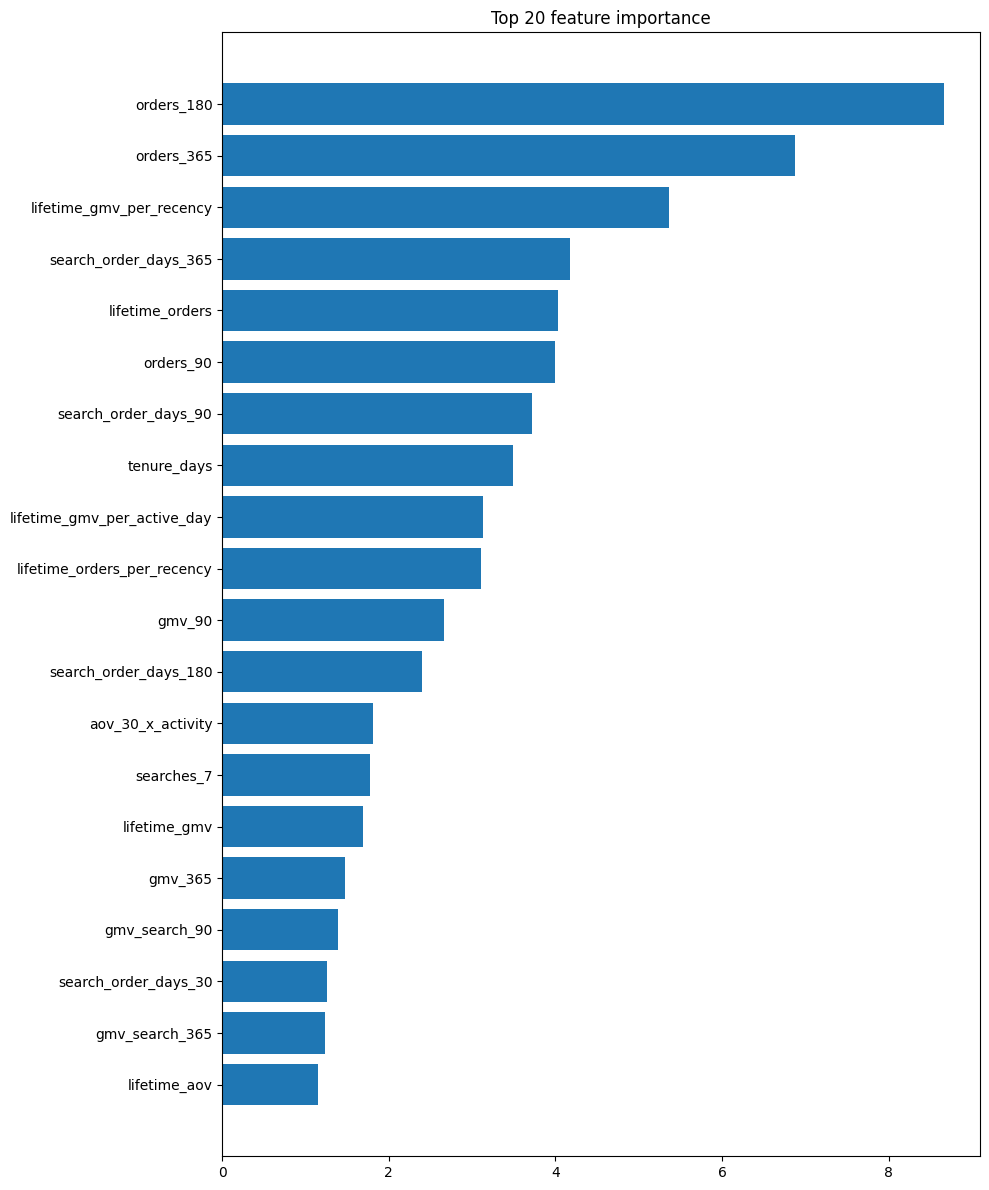

In [ ]:

feature_importance = pl.DataFrame({
    "feature": ENHANCED_FEATURES,
    "importance": cv["models"][-1].get_feature_importance(),
}).sort("importance", descending=True)

importance_path = SUBMISSIONS_DIR / "feature_importance.csv"
feature_importance.write_csv(importance_path)
print(f"Feature importance saved: {importance_path}")

print("\nTop 20 features:")
print(feature_importance.head(20))

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 12))
plt.barh(range(20), feature_importance.head(20)["importance"].to_numpy())
plt.yticks(range(20), feature_importance.head(20)["feature"].to_numpy())
plt.gca().invert_yaxis()
plt.title("Top 20 feature importance")
plt.tight_layout()
plt.show()

## Функция финального обучения

Функция объединяет обучающие snapshot-ы всех anchor-дата в одну таблицу.

Для каждого пользователя используются:

- выбранные признаки;
- фактический GMV за следующие 30 дней как target.

После объединения модель CatBoost обучается на `log1p(target_gmv)`,
поскольку это соответствует метрике RMSLE и уменьшает влияние пользователей
с очень большим GMV.

Функция возвращает обученную модель для последующего финального прогноза.

In [ ]:
def train_final_enhanced(anchors, features, iterations):
    train_parts = []

    for anchor in anchors:
        df = get_enhanced_snapshot(
            anchor,
            include_target=True,
        )

        train_parts.append(
            df.select(
                ["user_id"] + features + ["target_gmv"]
            )
        )

        del df
        gc.collect()

    train_all = pl.concat(
        train_parts,
        how="vertical_relaxed",
    )

    del train_parts
    gc.collect()

    X_train, y_train = prepare_xy(
        train_all,
        features,
    )

    final_model = CatBoostRegressor(
        iterations=iterations,
        learning_rate=MODEL_PARAMS["learning_rate"],
        depth=MODEL_PARAMS["depth"],
        l2_leaf_reg=MODEL_PARAMS["l2_leaf_reg"],
        loss_function="RMSE",
        random_seed=42,
        verbose=100,
        thread_count=2,
        border_count=64,
    )

    final_model.fit(
        X_train,
        np.log1p(y_train),
    )

    del train_all, X_train, y_train
    gc.collect()

    return final_model

## Финальное обучение и создание submission

Перед запуском проверяем, что:

- включён режим `full`;
- количество итераций получено по результатам временной валидации.

Затем модель обучается на всех anchor-дата, а признаки для прогноза
строятся на финальной дате после окончания исторического периода.

Предсказания переводятся обратно из логарифмической шкалы с помощью `expm1`.
Отрицательные значения заменяются нулём, после чего формируется CSV-файл
с колонками `user_id` и `predict`.

В конце выполняются проверки количества пользователей,
пропусков и диапазона предсказаний.

In [ ]:

if RUN_FINAL:
    if MODE != "full":
        raise RuntimeError(
            "Для финального обучения сначала запусти full validation: MODE='full'."
        )

    if 'final_iterations' not in globals():
        raise RuntimeError(
            "Сначала запусти CV, чтобы получить final_iterations. "
            "Запусти ячейку с run_cv перед финальным обучением."
        )

    print(
        f"Training final Enhanced model on {len(ALL_ANCHORS)} anchors..."
    )

    final_model = train_final_enhanced(
        ALL_ANCHORS,
        ENHANCED_FEATURES,
        final_iterations,
    )

    final_snap = get_enhanced_snapshot(
        FINAL_ANCHOR,
        include_target=False,
    )

    X_final = (
        final_snap
        .select(ENHANCED_FEATURES)
        .to_numpy()
        .astype(np.float32, copy=False)
    )

    pred_final = np.clip(
        np.expm1(final_model.predict(X_final)),
        0,
        None,
    )

    submission = (
        final_snap
        .select("user_id")
        .with_columns(
            pl.Series(
                "predict",
                pred_final,
            )
        )
        .select(["user_id", "predict"])
    )

    submission_path = (
        SUBMISSIONS_DIR
        / "submission_exp7_enhanced.csv"
    )

    submission.write_csv(submission_path)

    print(f"Saved: {submission_path}")
    print(f"Rows: {submission.height:,}")
    print(
        f"Unique users: "
        f"{submission['user_id'].n_unique():,}"
    )
    print(
        f"Null predictions: "
        f"{submission['predict'].null_count()}"
    )
    print(
        f"Min={pred_final.min():.6f} | "
        f"Median={np.median(pred_final):.6f} | "
        f"Mean={pred_final.mean():.6f} | "
        f"Max={pred_final.max():.6f}"
    )

    del final_model, final_snap, X_final, pred_final, submission
    gc.collect()
else:
    print(
        "RUN_FINAL=False — финальное обучение и submission пропущены."
    )

Training final Enhanced model on 9 anchors...
cached enhanced: 2025-10-01
cached enhanced: 2025-10-15
cached enhanced: 2025-10-29
cached enhanced: 2025-11-12
cached enhanced: 2025-11-26
cached enhanced: 2025-12-10
cached enhanced: 2025-12-24
cached enhanced: 2026-01-07
cached enhanced: 2026-01-14
0:	learn: 2.3101628	total: 1.63s	remaining: 54m 23s
100:	learn: 1.7322024	total: 2m 43s	remaining: 51m 18s
200:	learn: 1.7251991	total: 5m 10s	remaining: 46m 19s
300:	learn: 1.7230134	total: 7m 37s	remaining: 42m 57s
400:	learn: 1.7216044	total: 9m 59s	remaining: 39m 45s
500:	learn: 1.7203863	total: 12m 28s	remaining: 37m 16s
600:	learn: 1.7192489	total: 14m 50s	remaining: 34m 30s
700:	learn: 1.7182254	total: 17m 13s	remaining: 31m 52s
800:	learn: 1.7172985	total: 19m 38s	remaining: 29m 20s
900:	learn: 1.7164379	total: 22m 2s	remaining: 26m 49s
1000:	learn: 1.7156050	total: 24m 29s	remaining: 24m 23s
1100:	learn: 1.7148185	total: 26m 54s	remaining: 21m 55s
1200:	learn: 1.7140632	total: 29m 21s

In [ ]:
final_model_clean_4 = train_final_enhanced(
    ALL_ANCHORS,
    ENHANCED_FEATURES_CLEAN_4,
    final_iterations,
)

cached enhanced: 2025-10-01
cached enhanced: 2025-10-15
cached enhanced: 2025-10-29
cached enhanced: 2025-11-12
cached enhanced: 2025-11-26
cached enhanced: 2025-12-10
cached enhanced: 2025-12-24
cached enhanced: 2026-01-07
cached enhanced: 2026-01-14
0:	learn: 2.3101108	total: 2.23s	remaining: 1h 14m 28s
100:	learn: 1.7326639	total: 2m 23s	remaining: 45m 4s
200:	learn: 1.7255495	total: 4m 33s	remaining: 40m 51s
300:	learn: 1.7233140	total: 6m 41s	remaining: 37m 44s
400:	learn: 1.7218654	total: 8m 47s	remaining: 35m 3s
500:	learn: 1.7206151	total: 10m 55s	remaining: 32m 41s
600:	learn: 1.7194675	total: 13m 3s	remaining: 30m 24s
700:	learn: 1.7184549	total: 15m 7s	remaining: 28m 1s
800:	learn: 1.7175374	total: 17m 13s	remaining: 25m 46s
900:	learn: 1.7166599	total: 19m 21s	remaining: 23m 37s
1000:	learn: 1.7158401	total: 21m 32s	remaining: 21m 30s
1100:	learn: 1.7150616	total: 23m 43s	remaining: 19m 22s
1200:	learn: 1.7143179	total: 25m 52s	remaining: 17m 12s
1300:	learn: 1.7136030	tota

## Формирование финального прогноза

Создаём snapshot на финальную дату и рассчитываем признаки
только по доступной истории до 13 февраля 2026 года.

Затем модель прогнозирует GMV пользователя на следующие 30 дней.

In [ ]:
final_snap = get_enhanced_snapshot(
    FINAL_ANCHOR,
    include_target=False,
)

X_final = (
    final_snap
    .select(ENHANCED_FEATURES_CLEAN_4)
    .to_numpy()
    .astype(np.float32, copy=False)
)

pred_clean_4 = np.clip(
    np.expm1(final_model_clean_4.predict(X_final)),
    0,
    None,
)

submission_clean_4 = pl.DataFrame({
    "user_id": final_snap["user_id"],
    "predict": pred_clean_4,
})

model_path = SUBMISSIONS_DIR / "model_clean_4.cbm"
submission_path = SUBMISSIONS_DIR / "submission_clean_4.csv"

final_model_clean_4.save_model(str(model_path))
submission_clean_4.write_csv(submission_path)

print("Saved model:", model_path)
print("Saved submission:", submission_path)
print("Rows:", submission_clean_4.height)
print("Unique users:", submission_clean_4["user_id"].n_unique())
print("Null predictions:", submission_clean_4["predict"].null_count())
print(
    f"min={pred_clean_4.min():.6f}; "
    f"median={np.median(pred_clean_4):.6f}; "
    f"mean={pred_clean_4.mean():.6f}; "
    f"max={pred_clean_4.max():.6f}"
)

cached: 2026-02-14
saved enhanced: snapshot_enhanced_2026-02-14.parquet | rows=250,000 | cols=108
Saved model: /content/drive/MyDrive/Colab Notebooks/e-cup/submissions/model_clean_4.cbm
Saved submission: /content/drive/MyDrive/Colab Notebooks/e-cup/submissions/submission_clean_4.csv
Rows: 250000
Unique users: 250000
Null predictions: 0
min=0.000000; median=6.597773; mean=35.418915; max=6328.149340


## Формирование финального прогноза

Создаём snapshot на финальную дату и рассчитываем признаки
только по доступной истории до 13 февраля 2026 года.

Затем модель прогнозирует GMV пользователя на следующие 30 дней.

In [ ]:
sub_clean = pl.read_csv(SUBMISSIONS_DIR / "submission_clean_4.csv")

print("rows:", sub_clean.height)
print("unique users:", sub_clean["user_id"].n_unique())
print("nulls in predict:", sub_clean["predict"].null_count())
print("min/median/mean/max:",
      sub_clean["predict"].min(),
      sub_clean["predict"].median(),
      sub_clean["predict"].mean(),
      sub_clean["predict"].max())

rows: 250000
unique users: 250000
nulls in predict: 0
min/median/mean/max: 0.0 6.597773017779142 35.41891507147769 6328.149339520385


## Ансамбли

In [ ]:
base = (
    pl.read_csv(SUBMISSIONS_DIR / "submission_catboost_v1.csv")
    .select(["user_id", "predict"])
    .rename({"predict": "pred_base"})
)

enhanced = (
    pl.read_csv(SUBMISSIONS_DIR / "submission_exp7_enhanced.csv")
    .select(["user_id", "predict"])
    .rename({"predict": "pred_enhanced"})
)

clean = (
    pl.read_csv(SUBMISSIONS_DIR / "submission_clean_4.csv")
    .select(["user_id", "predict"])
    .rename({"predict": "pred_clean"})
)

preds = (
    base
    .join(enhanced, on="user_id", how="inner")
    .join(clean, on="user_id", how="inner")
)

assert preds.height == base.height == enhanced.height == clean.height
assert preds["user_id"].n_unique() == preds.height

In [ ]:
def save_blend(name, w_base, w_enhanced, w_clean):
    total = w_base + w_enhanced + w_clean
    if not np.isclose(total, 1.0):
        raise ValueError(f"Weights must sum to 1, got {total}")

    pred = np.clip(
        w_base * preds["pred_base"].to_numpy()
        + w_enhanced * preds["pred_enhanced"].to_numpy()
        + w_clean * preds["pred_clean"].to_numpy(),
        0,
        None,
    )

    out = pl.DataFrame({
        "user_id": preds["user_id"],
        "predict": pred,
    })

    path = SUBMISSIONS_DIR / name
    out.write_csv(path)

    print(
        f"{name}\n"
        f"weights: base={w_base:.2f}, enh={w_enhanced:.2f}, clean={w_clean:.2f}\n"
        f"rows={out.height:,}, mean={pred.mean():.6f}, "
        f"median={np.median(pred):.6f}, max={pred.max():.6f}"
    )

In [ ]:
# 1. Base + Clean-4 (проверка замены Full Enhanced)
save_blend(
    "submission_blend_base30_clean70.csv",
    w_base=0.30,
    w_enhanced=0.00,
    w_clean=0.70,
)

# 2. Тройной ансамбль
save_blend(
    "submission_blend_base20_enh50_clean30.csv",
    w_base=0.20,
    w_enhanced=0.50,
    w_clean=0.30,
)

# 4. Усиленный Full Enhanced (проверка, есть ли запас у 30/70)
save_blend(
    "submission_blend_base25_enh75.csv",
    w_base=0.25,
    w_enhanced=0.75,
    w_clean=0.00,
)

# 5. Лучший blend
save_blend(
    "submission_blend_base30_enh70.csv",
    w_base=0.30,
    w_enhanced=0.70,
    w_clean=0.00,
)

submission_blend_base30_clean70.csv
weights: base=0.30, enh=0.00, clean=0.70
rows=250,000, mean=35.421879, median=6.569569, max=5491.207595
submission_blend_base20_enh50_clean30.csv
weights: base=0.20, enh=0.50, clean=0.30
rows=250,000, mean=35.375629, median=6.603516, max=4985.706464
submission_blend_base25_enh75.csv
weights: base=0.25, enh=0.75, clean=0.00
rows=250,000, mean=35.353492, median=6.597391, max=4453.975318
submission_blend_base30_enh70.csv
weights: base=0.30, enh=0.70, clean=0.00
rows=250,000, mean=35.358512, median=6.592266, max=4392.933198


In [ ]:
save_blend(
    "submission_blend_base20_enh80.csv",
    w_base=0.20,
    w_enhanced=0.80,
    w_clean=0.00,
)

submission_blend_base20_enh80.csv
weights: base=0.20, enh=0.80, clean=0.00
rows=250,000, mean=35.348472, median=6.610737, max=4515.017437
